# Recommendation Systems using Collaborative Filtering
## Scenario 1: User-Based CF
## Scenario 2: Item-Based CF
Includes: RMSE, MAE, Precision@K, Visualizations

In [1]:
!wget http://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip -o ml-100k.zip

--2026-03-29 11:38:15--  http://files.grouplens.org/datasets/movielens/ml-100k.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://files.grouplens.org/datasets/movielens/ml-100k.zip [following]
--2026-03-29 11:38:15--  https://files.grouplens.org/datasets/movielens/ml-100k.zip
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4924029 (4.7M) [application/zip]
Saving to: ‘ml-100k.zip’

ml-100k.zip         100%[===================>]   4.70M  14.1MB/s    in 0.3s    

2026-03-29 11:38:15 (14.1 MB/s) - ‘ml-100k.zip’ saved [4924029/4924029]

Archive:  ml-100k.zip
   creating: ml-100k/
  inflating: ml-100k/allbut.pl       
  inflating: ml-100k/mku.sh          
  inflating: ml-100k/README          
  inflating: ml

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

## Load Dataset

In [3]:
ratings = pd.read_csv('ml-100k/u.data', sep='\t', names=['user_id','movie_id','rating','timestamp'])
movies = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1', names=['movie_id','title'] + [f'col{i}' for i in range(22)])
movies = movies[['movie_id','title']]
data = pd.merge(ratings, movies, on='movie_id')
data.head()

,user_id,movie_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


## User-Based CF

In [4]:
user_item = data.pivot_table(index='user_id', columns='title', values='rating')
user_item_filled = user_item.fillna(0)
user_sim = cosine_similarity(user_item_filled)
user_sim_df = pd.DataFrame(user_sim, index=user_item.index, columns=user_item.index)

In [5]:
def predict_user(user, movie):
    sims = user_sim_df[user].sort_values(ascending=False)[1:6]
    num, den = 0,0
    for u,s in sims.items():
        r = user_item.loc[u, movie]
        if not np.isnan(r):
            num += s*r
            den += s
    return num/den if den!=0 else 0

In [6]:
def recommend_user(user, n=5):
    unseen = user_item.loc[user][user_item.loc[user].isna()].index
    scores = {m:predict_user(user,m) for m in unseen}
    return sorted(scores.items(), key=lambda x:x[1], reverse=True)[:n]
recommend_user(1)

[('Casablanca (1942)', np.float64(5.000000000000001)),
 ('Alien: Resurrection (1997)', np.float64(5.0)),
 ('Chinatown (1974)', np.float64(5.0)),
 ('City of Lost Children, The (1995)', np.float64(5.0)),
 ('Diva (1981)', np.float64(5.0))]

## Item-Based CF

In [7]:
item_user = data.pivot_table(index='title', columns='user_id', values='rating').fillna(0)
item_sim = cosine_similarity(item_user)
item_sim_df = pd.DataFrame(item_sim, index=item_user.index, columns=item_user.index)

In [8]:
def recommend_item(user, n=5):
    user_r = user_item.loc[user].dropna()
    scores = {}
    for m,r in user_r.items():
        sims = item_sim_df[m].sort_values(ascending=False)[1:6]
        for sm,s in sims.items():
            if sm not in user_r:
                scores[sm] = scores.get(sm,0)+s*r
    return sorted(scores.items(), key=lambda x:x[1], reverse=True)[:n]
recommend_item(1)

[('E.T. the Extra-Terrestrial (1982)', 26.232914007579573),
 ('Mission: Impossible (1996)', 21.465240016931897),
 ('Batman (1989)', 19.7100293109673),
 ('Mrs. Doubtfire (1993)', 19.450666384695527),
 ('True Lies (1994)', 18.71973936616929)]

## Evaluation

In [9]:
actual, pred = [], []
for u in user_item.index[:50]:
    for m in user_item.columns[:50]:
        if not np.isnan(user_item.loc[u,m]):
            actual.append(user_item.loc[u,m])
            pred.append(predict_user(u,m))
rmse = sqrt(mean_squared_error(actual,pred))
mae = mean_absolute_error(actual,pred)
print('RMSE:',rmse)
print('MAE:',mae)

RMSE: 1.4747900573938357
MAE: 1.0902628761120756


In [10]:
def precision_at_k(user, k=5):
    recs = [m for m,_ in recommend_item(user,k)]
    actual = user_item.loc[user].dropna().index
    hits = len(set(recs)&set(actual))
    return hits/k
print('Precision@5:', precision_at_k(1))

Precision@5: 0.0


## Visualization

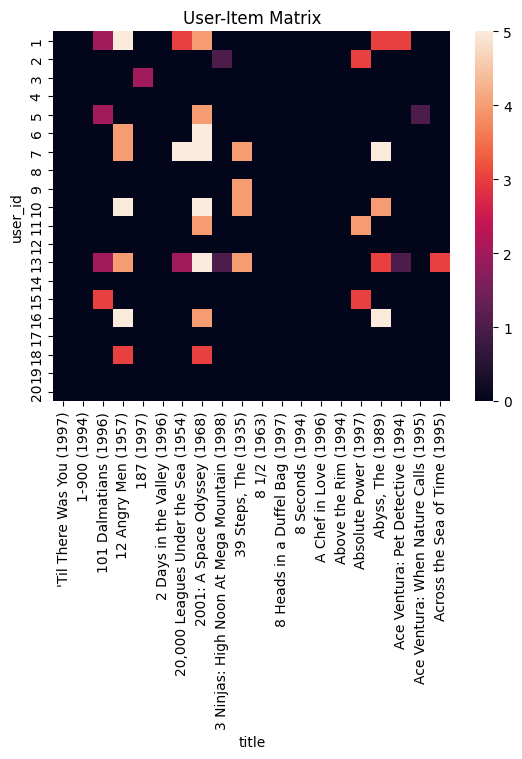

In [11]:
plt.figure()
sns.heatmap(user_item_filled.iloc[:20,:20])
plt.title('User-Item Matrix')
plt.show()

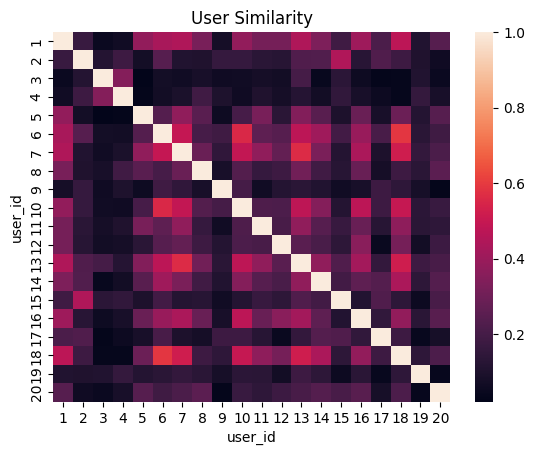

In [12]:
plt.figure()
sns.heatmap(user_sim_df.iloc[:20,:20])
plt.title('User Similarity')
plt.show()